In [1]:
import numpy as np

In [2]:
import xarray as xr

In [3]:
originaleof = 'data/zeof/ERA5.EOF1.z10.Mon06.nc'

In [4]:
myeof = 'processed/zeof/ERA5.EOF1.z10.Mon06.nc'

In [5]:
oeof = xr.open_dataset(originaleof)

In [6]:
meof = xr.open_dataset(myeof)

In [7]:
ratio = meof['eof1']/oeof['eof1']

In [8]:
oeof['eof1'][-10]#.sel(lat=slice(-90,-60)).values

<xarray.DataArray 'eof1' (lon: 360)> Size: 1kB
[360 values with dtype=float32]
Coordinates:
    lat      float32 4B -29.0
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [10]:
meof['eof1']

<xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
[6480 values with dtype=float32]
Coordinates:
    mode     int64 8B ...
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [11]:
ratio

<xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
array([[2.0031245e+00, 1.9973968e+00, 1.9931856e+00, ..., 2.0252953e+00,
        2.0340676e+00, 2.0286908e+00],
       [1.9854116e+00, 1.9570190e+00, 1.9762017e+00, ..., 2.0002980e+00,
        2.0230958e+00, 1.9970535e+00],
       [2.0120301e+00, 2.1193523e+00, 2.1118782e+00, ..., 2.0384214e+00,
        2.0431857e+00, 2.0409210e+00],
       ...,
       [2.0174053e+00, 2.0152113e+00, 2.0156419e+00, ..., 2.0146239e+00,
        2.0125642e+00, 2.0148785e+00],
       [2.0123107e+00, 2.0140016e+00, 2.0149174e+00, ..., 2.0140424e+00,
        2.0144949e+00, 2.0153933e+00],
       [3.1214167e-05, 3.1214167e-05, 3.1214167e-05, ..., 3.1214167e-05,
        3.1214167e-05, 3.1214167e-05]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    mode     int64 8B ...

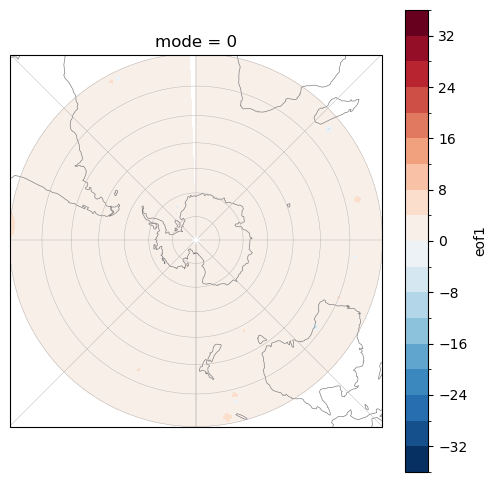

In [12]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = ratio.sel(lat=slice(-20,-88)).plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [13]:
np.sum(meof['eof1'])

<xarray.DataArray 'eof1' ()> Size: 4B
array(31.655571, dtype=float32)
Coordinates:
    mode     int64 8B ...

In [14]:
np.sum(oeof['eof1'])

<xarray.DataArray 'eof1' ()> Size: 4B
array(63.281883, dtype=float32)

In [15]:
w = np.cos(np.deg2rad(meof['lat']))

In [16]:
coslat = np.cos(np.deg2rad(meof.coords['lat'].values)).clip(0., 1.)
wgts = np.sqrt(coslat)[..., np.newaxis]

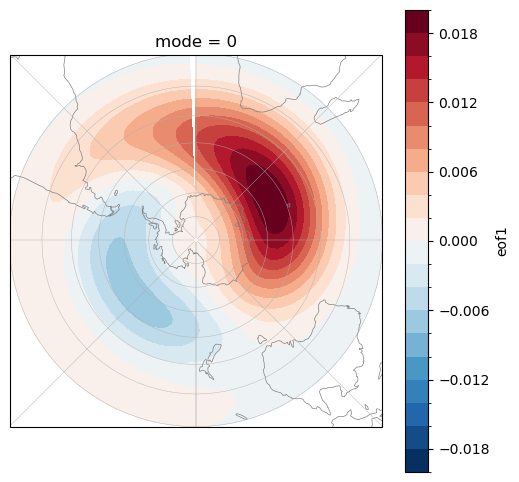

In [17]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = (meof['eof1']/2).plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

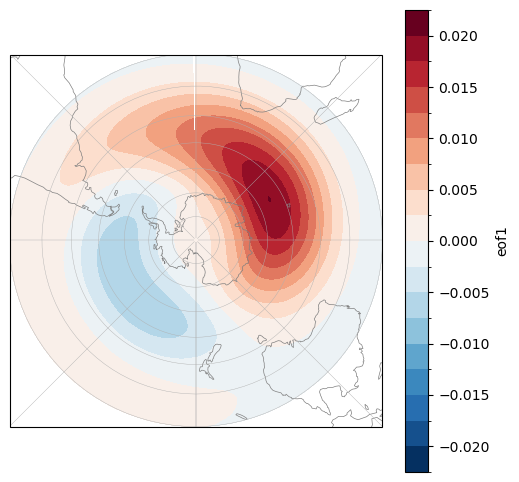

In [18]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = oeof['eof1'].plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [19]:
np.sum((meof['eof1']/2) - oeof['eof1'])

<xarray.DataArray 'eof1' ()> Size: 4B
array(0.05279766, dtype=float32)
Coordinates:
    mode     int64 8B 0

In [20]:
meof['eof1']/ oeof['eof1']

<xarray.DataArray 'eof1' (lat: 36, lon: 180)> Size: 26kB
array([[2.0031245e+00, 1.9973968e+00, 1.9931856e+00, ..., 2.0252953e+00,
        2.0340676e+00, 2.0286908e+00],
       [1.9854116e+00, 1.9570190e+00, 1.9762017e+00, ..., 2.0002980e+00,
        2.0230958e+00, 1.9970535e+00],
       [2.0120301e+00, 2.1193523e+00, 2.1118782e+00, ..., 2.0384214e+00,
        2.0431857e+00, 2.0409210e+00],
       ...,
       [2.0174053e+00, 2.0152113e+00, 2.0156419e+00, ..., 2.0146239e+00,
        2.0125642e+00, 2.0148785e+00],
       [2.0123107e+00, 2.0140016e+00, 2.0149174e+00, ..., 2.0140424e+00,
        2.0144949e+00, 2.0153933e+00],
       [3.1214167e-05, 3.1214167e-05, 3.1214167e-05, ..., 3.1214167e-05,
        3.1214167e-05, 3.1214167e-05]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    mode     int64 8B 0